# Model-independent GEDF reconstruction tests

This notebook validates the PCHIP reconstruction, density-fraction shooting at $z_i$, and numerical GEDF perturbations using the `drdm` build of CLASS.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / 'test'))
from test_model_independent_gedf import PARAMS
from classy import Class

model = Class()
model.set(PARAMS)
model.compute()
background = model.get_background()
scalar = model.get_perturbations()['scalar'][0]
print('CLASS model computed; scalar samples:', len(scalar['a']))

CLASS model computed; scalar samples: 5343


In [2]:
z = background['z']
w = background['(.)w_gedf']
rho = background['(.)rho_gedf']
rho_tot = background['(.)rho_tot']
control_z = np.array([5000., 3000., 1800., 900., 500.])
control_w = np.array([-0.9, -0.2, 1/3, 0.1, 0.])
recovered_w = np.interp(control_z, z[::-1], w[::-1])
fraction_at_zi = np.interp(5000., z[::-1], (rho/rho_tot)[::-1])
max_node_error = np.max(np.abs(recovered_w-control_w))
assert max_node_error < 3e-4
assert abs(fraction_at_zi-0.03) < 3e-5
assert np.all(np.isfinite(w)) and np.all(np.isfinite(rho))
print(f'max control-point error = {max_node_error:.3e}')
print(f'f_GEDF(z_i) = {fraction_at_zi:.9f}')

max control-point error = 4.353e-07
f_GEDF(z_i) = 0.030000030


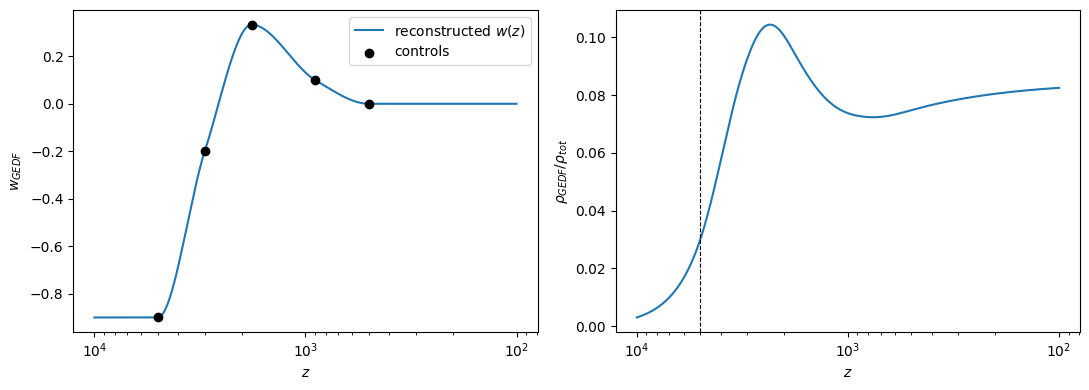

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mask = (z >= 100) & (z <= 10000)
axes[0].semilogx(z[mask], w[mask], label='reconstructed $w(z)$')
axes[0].scatter(control_z, control_w, color='black', zorder=3, label='controls')
axes[0].invert_xaxis(); axes[0].set(xlabel='$z$', ylabel='$w_{GEDF}$')
axes[0].legend()
axes[1].semilogx(z[mask], (rho/rho_tot)[mask])
axes[1].axvline(5000., color='black', ls='--', lw=0.8)
axes[1].invert_xaxis(); axes[1].set(xlabel='$z$', ylabel=r'$\rho_{GEDF}/\rho_{tot}$')
fig.tight_layout()

PASS: all reconstructed GEDF background and perturbation checks are finite.


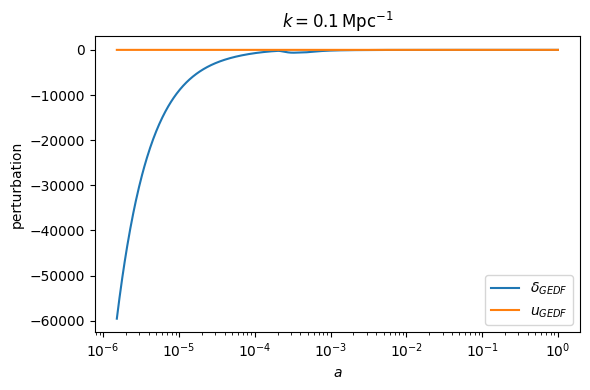

In [4]:
fields = ['delta_gedf', 'delta_rho_gedf', 'rho_plus_p_theta_gedf',
          'delta_p_gedf', 'ca2_gedf_output', 'u_gedf']
for field in fields:
    assert np.all(np.isfinite(scalar[field])), field
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(scalar['a'], scalar['delta_gedf'], label=r'$\delta_{GEDF}$')
ax.semilogx(scalar['a'], scalar['u_gedf'], label='$u_{GEDF}$')
ax.set(xlabel='$a$', ylabel='perturbation', title=r'$k=0.1\,\mathrm{Mpc}^{-1}$')
ax.legend(); fig.tight_layout()
print('PASS: all reconstructed GEDF background and perturbation checks are finite.')
model.struct_cleanup(); model.empty()